# Tutorial: Graph Neural Networks (GNN) with PyG
> Created: Oct 2025 for the FSU Course: *Machine Learning in Physics* <br>
> Harrison B. Prosper<br>

## Introduction
In this tutorial we build a **graph neural network** (GNN) mathematically identitical to the one in `06.GNN` but  using **PyTorch Geometric** (PyG). See `06.GNN/code/tutorial_GNN.ipynb` for details.
Our goal is to classify events as **signal** or **background**, where each event is modeled as a list of data pertaining to particles: the transverse momentum of a particle, $p_T$ and its direction $(\eta, \phi)$. The quantity $\eta = -\log\tan (\theta/2)$ is the pseudo-rapidity, $\theta$ the polar angle, and $\phi$ the azimuthal angle. 

## Tips

  * Use __esc r__ to disable a cell
  * Use __esc y__ to reactivate it
  * Use __esc m__ to go to markdown mode. **Markdown** is the typesetting language used in jupyter notebooks.
  * In a markdown cell, double tap the mouse or glide pad (on your laptop) to go to edit mode.
  * Shift + return to execute a cell (including markdown cells).
  * If the equations don't typeset, try double tapping the cell again, and re-execute it.

## Installation of `mlinphysics`

### Local installation
  ```bash
      git clone https://github.com/hbprosper/mlinphysics
      cd mlinphysics
      pip install -e .
  ```

## Running on Google Colab
If on Google Colab (https://colab.research.google.com), execute cell below.

In [2]:
try:
    import google.colab

    REPO = 'hbprosper/mlinphysics'
    
    url = f"https://raw.githubusercontent.com/{REPO}/refs/heads/main"
    !wget -q {url}/clone2colab.ipynb -O clone2colab.ipynb
    %run clone2colab.ipynb
    
    IN_COLAB = True
    
except ImportError:
    
    IN_COLAB = False

# PART 1

In [3]:
import os, sys
import numpy as np
import importlib
import shutil
import matplotlib as mp
import matplotlib.pyplot as plt
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn

# PyG
from torch_geometric.nn import global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import scatter, softmax, subgraph

# ML in physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon
import mlinphysics.utils.tutorials as tut

# update fonts
plt.rcParams.update({
  "text.usetex": shutil.which('latex') is not None,
  "font.family": "sans-serif",
  #"font.sans-serif": "Helvetica",
  "font.size": 14
  })

## Computational device

In [4]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tAvailable device: {str(DEVICE):4s}\n')


	Available device: cpu 



## Load Events
The dataset comprises 36,000 events divided equally between signal and background that have been randomly shuffled. The targets can be accessed using the key 'targets' and an event is accessed by specifying the event number  'N', with the first event being '0'.

In [5]:
importlib.reload(dat)

datafile = '../data/events.h5'

dat.download(datafile)

print('\n\tLoad data\n')
events, targets = tut.load_events(datafile)

print(
    f'targets: {targets.shape}, 0: {events[0].shape}, 1: {events[1].shape}')


	Load data



100%|█████████████████████████████| 36000/36000 [00:04<00:00, 8031.90it/s]


	sample size:               36000
	min[multiplicity]:            29
	avg[multiplicity] +/-std:    148.3 +/-50.1    
	max[multiplicity]:           529
	avg[pT]:                      23.4 GeV
targets: (36000,), 0: (107, 3), 1: (128, 3)


## Plot Events

The particle's transverse momentum is proportional to the area of the markers.

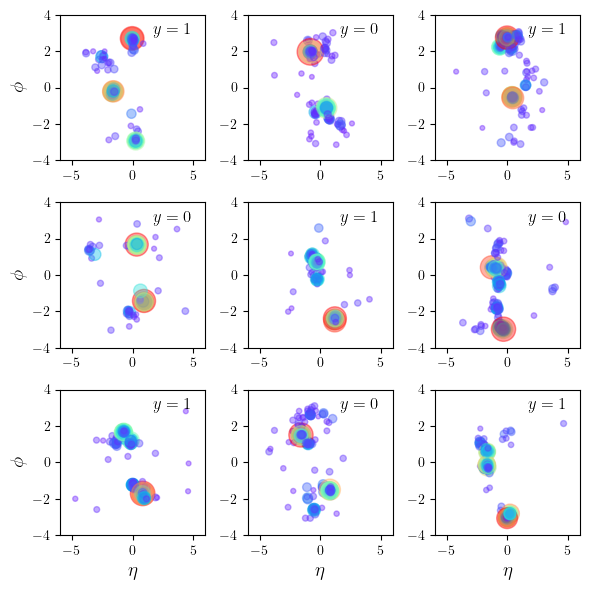

In [6]:
importlib.reload(tut)
tut.plot_events(events, targets)

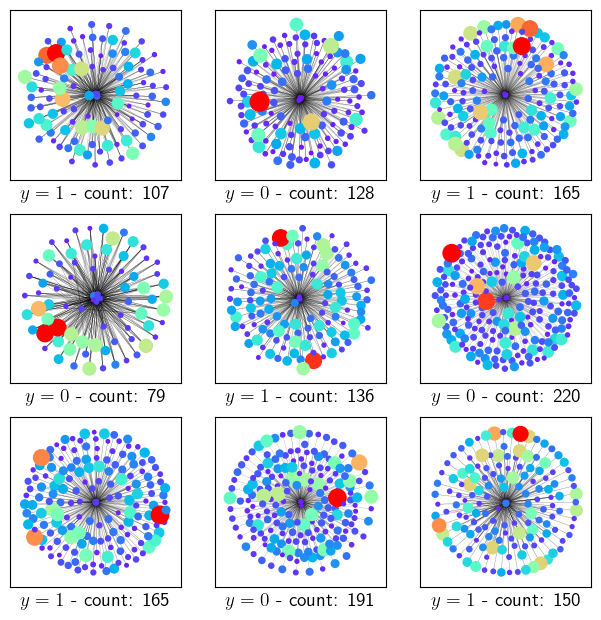

In [7]:
N = 9
x = [torch.tensor(events[i].reshape(1, -1, 3)) for i in range(N)]
y = torch.tensor(targets[:N].astype(int)).view(-1, 1)
tut.plot_graphs(zip(x, y), scale=8)

## Configuration

In [8]:
# name of model
# -----------------------------------------
name = 'sigbkg'

# create new configuration
config = mlp.Config(name, dirname='GNN')

# training configuration
# -----------------------------------------
config('train_size',   32_000) # training sample size
config('test_size',     3_900) # test sample size
config('val_size',        100) # validation sample size
config('batch_size',        2) # number of graphs / batch
config('monitor_step',    100) # monitor training every n (=10) iterations
config('frac', 0.01)           # save model if average loss decreases by
                               # more than fraction "frac"

# optimizer / scheduler configuration
# -----------------------------------------
n_iterations = 100_000
iterations_per_epoch = int(config('train_size') / config('batch_size'))

n_epochs = int(np.ceil(n_iterations / iterations_per_epoch))
config('n_epochs', n_epochs)

n_iterations = n_epochs * iterations_per_epoch
config('n_iterations', n_iterations)

# A step comprises a given number of iterations
n = 4
config('n_steps', n)                # number of training steps
config('n_iters_per_step', int(config('n_iterations') / config('n_steps')))

config('base_lr', 1.e-3)            # initial learning rate
if n > 1:
    gamma = (1/10)**(1/(n-1))       # Reduce learning rate by one order of magnitude
else:
    gamma = 1.0
config('gamma', gamma)              # learning rate scale factor

# learning rate scale factor
print(f'\nSave configuration to file {config('file/config')}\n')
config.save()

print(config)


Save configuration to file runs/GNN/sigbkg_config.yaml

name: sigbkg
file:
  config: runs/GNN/sigbkg_config.yaml
  losses: runs/GNN/sigbkg_losses.csv
  params: runs/GNN/sigbkg_params.pth
  init_params: runs/GNN/sigbkg_init_params.pth
  plots: runs/GNN/sigbkg_plots.png
train_size: 32000
test_size: 3900
val_size: 100
batch_size: 2
monitor_step: 100
frac: 0.01
n_epochs: 7
n_iterations: 112000
n_steps: 4
n_iters_per_step: 28000
base_lr: 0.001
gamma: 0.4641588833612779



## Prepare datasets and dataloaders
  1. Scale data.
  2. Build an inhomogeneous `numpy` array of events. Why?
  3. Split data into training, testing, and validation sets.

### Scale data

Scale events and convert data to 32-bit floats.

In [9]:
print('\n\tScale data')
#                  pT, eta,   phi
scale = np.array([[50,   5, np.pi]], dtype=np.float32)

sevents = [event.astype(np.float32) / scale for event in events]
targets = targets.astype(np.float32)


	Scale data


## Datasets

Create a dataset of graphs, one for every event. Every particle in an event is modeled as a node (or vertex) of a graph.

In [10]:
importlib.reload(tut)

print('\n\tTest FullConnection')

tevents    = torch.tensor(sevents[0])
connection = tut.FullConnection()
edge_index = connection(tevents)
weights    = tut.edge_weights(tevents, edge_index)

print(tevents.shape, edge_index.shape, weights.shape)


	Test FullConnection
torch.Size([107, 3]) torch.Size([2, 11449]) torch.Size([11449])


### Graph Dataset

A graph dataset is a list of `PyG` `Data` objects.

In [11]:
train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# training dataset (this defines the empirical risk to be minimized)
print('\n\tTraining data')
train_data = tut.GraphDataset(
    sevents, start=0, end=train_size, 
    targets=targets)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = tut.GraphDataset(
    sevents, start=0, end=train_size, random_sample_size=val_size, 
    targets=targets)

# validation dataset (for monitoring training)
print('validation data')
val_data = tut.GraphDataset(
    sevents, start=train_size, end=train_size + val_size, 
    targets=targets)

# test dataset
print('test data')
test_data= tut.GraphDataset(
    sevents, start=train_size + val_size, end=train_size + val_size + test_size,
    targets=targets)

print('train_data[0]:', train_data[0])


	Training data


100%|█████████████████████████████| 32000/32000 [00:06<00:00, 5174.82it/s]


Dataset
  shape of x: 32000
  shape of y: 32000

training data for validation


100%|█████████████████████████████████| 100/100 [00:00<00:00, 4497.82it/s]


Dataset
  shape of x: 100
  shape of y: 100

validation data


100%|█████████████████████████████████| 100/100 [00:00<00:00, 5211.03it/s]


Dataset
  shape of x: 100
  shape of y: 100

test data


100%|███████████████████████████████| 3900/3900 [00:00<00:00, 4731.23it/s]

Dataset
  shape of x: 3900
  shape of y: 3900

train_data[0]: Data(x=[107, 3], edge_index=[2, 11449], y=[1])


## DataLoaders

In [12]:
print('train data loader')
train_loader = DataLoader(
    train_data, batch_size=config('batch_size'), shuffle=True)

print('train data loader for validation')
train_loader_val = DataLoader(
    train_data_val, batch_size=len(train_data_val))

print('validation data loader')
val_loader = DataLoader(
    val_data, batch_size=len(val_data))

print('test data loader')
test_loader = DataLoader(test_data, batch_size=50)

train data loader
train data loader for validation
validation data loader
test data loader


In [13]:
batch = next(iter(train_loader))
batch.x.shape, batch.edge_index.shape, batch.y.shape, batch.batch.shape

(torch.Size([266, 3]),
 torch.Size([2, 36178]),
 torch.Size([2]),
 torch.Size([266]))

## Build Model

### Conceptual framework
Consider a graph $G = (V, E)$ with $n$   nodes (i.e., vertices) $V = \{V_0,\cdots, V_{n-1}\}$ and $K$ edges $E = \{E_0, \cdots, E_{K-1} \}$. An **edge** can be modeled as the triplet $(i, j, e_{(i,j)})$, where $i$ and $j$ are indices that identify the two connecting nodes $V_i$ and $V_j$, respectively, and $e_{(i,j)}$ are the attributes associated with the edge identified by the **edge index** $(i, j)$. If a **message** $M$ is passed from vertex $V_j$ to $V_i$,
$$V_j \rightarrow M \rightarrow V_i,$$
the vertex $V_j$ is called a **source node**, while the receiving vertex $V_i$ is called a **target node**. A message is a function of the attributes of a source node and attributes of the associated edge; in the simplest case  a message is a vector of scaled source attributes where the scaling is the edge attribute or **weight**.

Given a target node, all messages from the source nodes to which the target is connected are entered into an **aggregation** function which  creates a new vector of attributes that replaces the existing attributes of the target node.

### Adjacency matrix $A$
An event with $n$ particles can be modeled as a graph with $n$ nodes.  Inspired by IceCube, we model the attributes associated with edges of the graph as an $n \times n$ adjacency matrix $A$ where the matrix elements are given by
\begin{align}
    d_{ij} & = \exp(-\alpha \| x_i - x_j \|^2), \\
    e_{(i,j)} & = \texttt{softmax}(d_{ij}, \, \texttt{dim}=1) ,
\end{align}
where $x_i = (\eta_i, \phi_i)$ and $\alpha$ is a free parameter. An adjacency matrix implicitly encodes the edge index $(i, j)$ between nodes $i$ and $j$ and explicitly encodes the edge attributes $e_{(i,j)}$. In `PyG`, the edge index is defined with a tensor of shape $[2, K]$ called `edge_index` such that the target and source nodes, `trg_nodes` and `src_nodes`, respectively, are given by
```python
    trg_nodes, src_nodes = edge_index
```
The use of edge indices, basically the "address" of an element in the adjacency matrix, makes it possible for `PyG` to handle sparse adjacency matrices efficiently. 

But in this notebook we create graphs that are
**fully-connected**. This is not the ideal use case for `PyG`. Indeed, `PyG` runs an order of magnitude slower than the previous version  of the tutorial (`06.GNN/code/tutorial_GNN.ipynb`) which makes direct use of the adjacency matrix. However, the classification example is a pedagogically simple way to introduce PyTorch Geometric.

### Graph Convolution: $\texttt{GNNConv}$
We implement a graph convolutional layer that differs from the one implemented by IceCube.
As in most GNNs, the nodes are concatenated into a matrix, $V$, of shape $(n, d)$, where $n$ is the number of nodes and $d$ is the dimensionality of the input feature space. The graph convolution operation is defined by the following computations
\begin{align}
    A & = f(V),&\quad\text{node adjacency  }\\
    X & = \sigma(V W_1^T + B_1), &\quad\text{node embedding}\\
    X^\prime & = A X, &\quad\text{node attention  }\\
    Z & = X^\prime W_2^T + B_2,
\end{align}
that is, a linear function that maps the vertices of $V$ to a vector in an embedding space of dimension $h$, thereby yielding a matrix of shape $(n, h)$. Then a nonlinear operation, $\sigma(*)$, is applied (usually, elementwise) to every element of the embedded vectors. The adjacency matrix $A$, which we choose to be a function of the input nodes $V$, defines the *neighborhood* structure of the graph (see details above). The closer neighbors are weighted more than those further away. The learnable parameter $\alpha$ determines the scale of the nearest neighbor domains.    

Next we compute $X^\prime = AX$, which implements a simple **attention** mechanism in which each target node "pays attention" to its nearest neighbors. Finally, another linear operation is performed which embeds the vector in $X^\prime$ in another vector space.

In [14]:
class GNNConv(nn.Module):
    def __init__(self, in_features, embed_dim, out_features, 
                 activation=nn.ReLU()):

        super().__init__()

        self.activation = activation
        
        # we embed the "n" input vertices in a larger vector
        # space of dimension h = embed_dim
        self.embed_dim = embed_dim
        self.embed  = nn.Linear(in_features, embed_dim)
        self.linear = nn.Linear(embed_dim, out_features)

    def forward(self, V, edge_index, edge_attrs):
        # V[n=num_nodes, d=in_features]  - nodes in the current batch
        # edge_index[2, K=num_edges] - edges in the current batch
        # edge_attrs[K] - associated edge attributes

        trg_nodes, src_nodes = edge_index

        # 1: Embed input nodes in vector space of h = embed_dim dimensions
        X = self.activation(self.embed(V)) # X[num_nodes, embed_dim]

        # 2: Create messages associated with edges. Note: These edges
        #    may form self-consistent sub-graphs. (In the present context,
        #    a message from a source node to a target node is a scaled
        #    vector, weight * vector, in the embedding space but with
        #    the weight computed in the input space using the formula
        #    for e_(i,j) given above.)
        #
        #    Note: X has shape [num_nodes, embed_dim], while X[src_nodes]
        #    has shape [num_edges, embed_dim] and weights has shape
        #    [num_edges, ]. Therefore, we need to change the shape of
        #    weights to [num_edges, 1] so that every feature of a given
        #    source node is scaled by the weight associated with the
        #    associated edge.
        #
        #    Creating the messages and calling scatter is mathematically
        #    equivalent to computing X^prime = AX.

        messages = edge_attrs.unsqueeze(-1) * X[src_nodes]

        # 3. Send messages from all source nodes to the target nodes
        #    to which they are linked. Then aggregate these messages
        #    by summing them vectorially per target nodes. These
        #    operations, which are equivalent to computing A*X, can
        #    be done with the scatter function.
        #
        # calling sequence:
        #    torch_scatter.scatter(messages, trg_nodes, dim=0, reduce='sum')
        #
        #    dim=0 specifies that the messages to a given target node
        #    should be summed vertically, that is, along the dim=0 axis.

        X = scatter(messages, trg_nodes, dim=0, reduce='sum')

        # 4. Final transformation
        Z = self.linear(X)

        return Z

Test `GNNConv`

In [15]:
batch = next(iter(train_loader))
print('batch.x.device', batch.x.device,
      'batch.edge_index.device', batch.edge_index.device)
edge_attrs = tut.edge_weights(batch.x, batch.edge_index)

print(edge_attrs.shape, edge_attrs.dtype)
print(batch.x.shape, batch.x.dtype)
print(batch.y.shape, batch.y.dtype)

conv = GNNConv(3, 5, 2).to(DEVICE)
X = conv(batch.x, batch.edge_index, edge_attrs)

batch.x.device cpu batch.edge_index.device cpu
torch.Size([26361]) torch.float32
torch.Size([219, 3]) torch.float32
torch.Size([2]) torch.float32


### Build GNN

In [16]:
class GNN(mlp.Model):

    def __init__(self, in_features, embed_dim, out_features, 
                 activation=nn.SiLU(),
                 dropout=0.5,
                 alpha=1.0):

        # initialize base class
        super().__init__()

        self.activation = activation
        
        # Note use of nn.Parameter to tell PyTorch that the parameter
        # alpha is to be fitted.
        self.alpha  = nn.Parameter(alpha * torch.rand(1))

        self.conv1  = GNNConv(in_features, embed_dim, embed_dim)
        self.conv2  = GNNConv(embed_dim, embed_dim, embed_dim)
        self.dropout= nn.Dropout(dropout)
        self.output = nn.Sequential(nn.Linear(embed_dim, out_features),
                                    nn.Sigmoid())

    def forward(self, batch):
        V = batch.x
        # V[num_nodes, in_features]  : all nodes
        
        edge_index = batch.edge_index
        # edge_index[2, num_edges]       : [subset of] edges

        # Compute edge weights, which is equivalent to
        # computing the matrix A.
        edge_attrs = tut.edge_weights(V, edge_index, self.alpha)

        X = self.conv1(V, edge_index, edge_attrs)
        X = self.activation(X)
        X = self.dropout(X)

        X = self.conv2(X, edge_index, edge_attrs)
        X = self.activation(X)
        X = self.dropout(X)

        # average features over nodes
        X = global_mean_pool(X, batch.batch)

        y_pred = self.output(X)
        
        return y_pred

## Instantiate training objects
  1. `model`
  2. `optimizer`
  1. `objective`
  2. `scheduler`
  3. `monitor`

In [17]:
importlib.reload(mlp)

model = GNN(in_features=3, embed_dim=40, out_features=1).to(DEVICE)
print(model)
print('number of parameters:', mlp.number_of_parameters(model))
print()

optimizer = torch.optim.Adam(model.parameters(), lr=config('base_lr'))

# make a specialized objective from mlp.Objective
class GNNObjective(mlp.Objective):
    def __init__(self, model, avgloss):
        super().__init__(model, avgloss)

    def forward(self, batch):
        y_pred = self.model(batch).reshape(batch.y.shape)
        return self.avgloss(y_pred, batch.y)

objective = GNNObjective(model, nn.BCELoss()).to(DEVICE)

# Instantiate learning rate step scheduler
scheduler = mlp.LRStepScheduler(
    optimizer,  
    n_steps=config('n_steps'), 
    n_iters_per_step=config('n_iters_per_step'), 
    base_lr=config('base_lr'), 
    gamma=config('gamma')
)

# Instantiate object that saves average losses to
# a csv file for realtime monitoring, as well as
# the model with the lowest average loss
monitor = mon.Monitor(
    config('n_iterations'),
    config('file/losses'),
    monitorstep=config('monitor_step'),
    newlossfile=True,
    frac=config('frac'),
    model=model,
    paramsfile=config('file/params')
)

GNN(
  (activation): SiLU()
  (conv1): GNNConv(
    (activation): ReLU()
    (embed): Linear(in_features=3, out_features=40, bias=True)
    (linear): Linear(in_features=40, out_features=40, bias=True)
  )
  (conv2): GNNConv(
    (activation): ReLU()
    (embed): Linear(in_features=40, out_features=40, bias=True)
    (linear): Linear(in_features=40, out_features=40, bias=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (output): Sequential(
    (0): Linear(in_features=40, out_features=1, bias=True)
    (1): Sigmoid()
  )
)
number of parameters: 5122

number of milestones:          3

Step | Milestone | LR
-----------------------------
   0 |         0 | 1.0e-03   
-----------------------------
   1 |     28000 | 4.6e-04   
   2 |     56000 | 2.2e-04   
   3 |     84000 | 1.0e-04   



## Define trainer

In [19]:
importlib.reload(mlp)

def train(objective, optimizer, scheduler, monitor,
          train_loader, train_small_loader, val_loader, nepochs):

    for epoch in range(nepochs):
        
        for batch in train_loader:
            
            objective.train()
            
            R = objective(batch)
            
            optimizer.zero_grad()     # zero gradients
            
            R.backward()              # compute gradients
    
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
    
            optimizer.step()          # make a single step in average loss
    
            # check whether to update learning rate
            scheduler.step()
    
            if monitor.step():
    
                # set mode to evaluation so that training-specific
                # operations such as dropout, etc., are disabled.
                objective.eval()
    
                batch = next(iter(train_small_loader))
                t_loss = objective(batch).item()
     
                batch = next(iter(val_loader))
                v_loss = objective(batch).item()
    
                # return current learning rate
                lr = scheduler.lr()
    
                # update loss file
                monitor(t_loss, v_loss, lr, epoch)
    print()

## Train Model

In [ ]:
TRAIN = True

if TRAIN:

    monitor.start()
    
    train(objective, optimizer, scheduler, monitor,
          train_loader, train_loader_val, val_loader, n_epochs)

    monitor.end()

monlosses runs/GNN/sigbkg_losses.csv

		learning rate:  1.000e-03
      1100|  0.98%|00:00:42|01:11:16|  25.9 it/s|5.756e-01|4.760e-01|         0|

## Plot Results

  1. Confusion matrix for signals defined by $y \geq 1/2$.
  2. Classifier distribution $\hat{y} = D(G)$.
  3. ROC curve

In [21]:
importlib.reload(tut)

params_filename = config('file/params')

model.load(params_filename)

y_hat = []
label = []
for ii, batch in enumerate(tqdm(test_loader)):
    label.append( batch.y.detach().cpu().numpy().flatten() )
    y_hat.append( model(batch).detach().cpu().numpy().flatten() )

y_hat = np.array(y_hat).flatten()
test_targets = np.array(label).flatten()

y_hat.shape, test_targets.shape

100%|█████████████████████████████████████| 78/78 [00:11<00:00,  6.85it/s]


((3900,), (3900,))

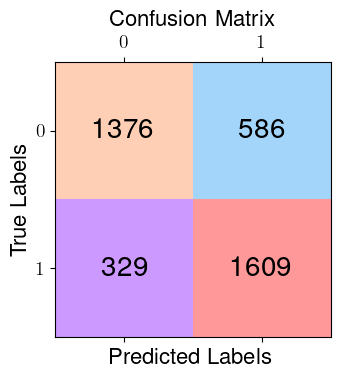

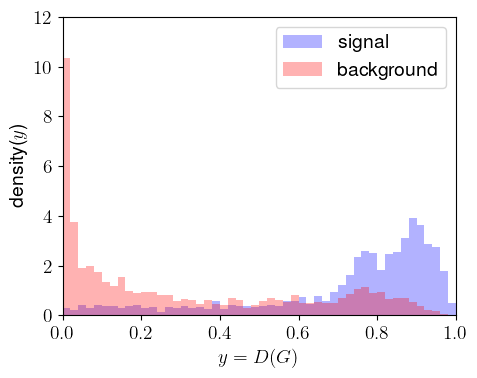

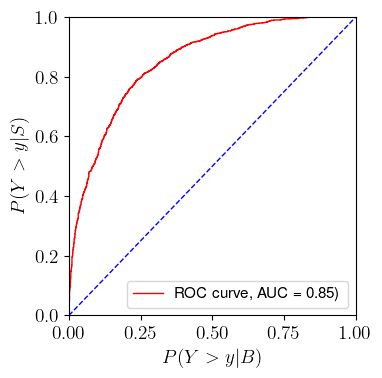

In [22]:
test_preds = (y_hat > 0.5).astype(int)

tut.plot_confusion_matrix(test_targets, test_preds)
tut.histogram_classifier_outputs(test_targets, y_hat)
tut.plot_roc(test_targets, y_hat)